# Cross-sectional commodity momentum — a quantitative teardown 🔬
### The 12-1 L/S sort with HAC *t* · a leg decomposition · a 40-seed random-rank placebo · a pre/post-2019 difference test · a cost-and-borrow sweep · a planted-effect synthetic control

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Recent half: Not supported](https://img.shields.io/badge/Recent_half-Not_supported-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The claim — **Miffre-Rallis (2007): a 12-1 cross-sectional commodity-momentum sort pays** — is a *pure commodity* momentum sleeve, distinct from the mixed multi-asset combo of [638](../../638-value-momentum-everywhere/), the equity sort of [507](../../507-cross-sectional-momentum/), and the single-commodity seasonals (226/307/648-651). The job: measure it with an autocorrelation-robust *t*, prove the machinery, and grade tradability honestly.

> ⚠️ **Data note.** 13 single-commodity ETFs, total-return closes (yfinance `auto_adjust=True`), 2009-04 → 2026-06, 207 monthly rebalances, cached. **Survivorship named on the Signal axis** — current-membership basket, premium is an upper bound. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md) (fingerprint `1c68bd1531bb`).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from commodity_momentum import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PRICES = data.load_prices()
    MRET = data.monthly_returns(PRICES)
else:
    PRICES = MRET = None
print("real cache present:", HAVE_REAL, "| monthly panel:",
      (None if MRET is None else f"{MRET.shape[0]} months x {MRET.shape[1]} ETFs"))

# frozen headline numbers (mirror of docs/results.md)
R = {'as_of': '2026-06-30', 'ls_start': '2009-04-30', 'ls_end': '2026-06-30', 'n_months': 207, 'n_etfs': 13, 'panel_months': 220, 'mean_bps': 84.22, 'ann_pct': 10.11, 'hac_t': 1.655, 'hac_lags': 4, 'one_sample_t': 1.7, 'sharpe': 0.409, 'hit_pct': 54.6, 'turnover': 0.74, 'long_bps': 37.21, 'long_t': 1.33, 'short_bps': 47.01, 'short_t': 1.67, 'basket_ann': 3.29, 'placebo_seeds': 40, 'placebo_real_t': 1.655, 'placebo_mean_t': 0.108, 'placebo_sd_t': 0.913, 'placebo_mean_sharpe': 0.021, 'placebo_frac_ge2': 0.0, 'placebo_p': 0.025, 'era_split': '2019-01-01', 'early_n': 117, 'early_bps': 119.0, 'early_t': 2.27, 'early_sharpe': 0.64, 'late_n': 90, 'late_bps': 39.0, 'late_t': 0.43, 'late_sharpe': 0.17, 'diff_t': -0.78, 'timer5_gross': 10.11, 'timer5_net': 9.16, 'timer5_t': 1.5, 'timer5_sharpe': 0.37, 'timer10_gross': 10.11, 'timer10_net': 8.72, 'timer10_t': 1.42, 'timer10_sharpe': 0.35, 'syn_null_mean': -0.0, 'syn_null_sd': 1.35, 'syn_null_fire': 2, 'syn_planted_t': 13.34, 'syn_planted_bps': 800.16, 'syn_planted_sharpe': 5.21, 'fp': '1c68bd1531bb'}


real cache present: True | monthly panel: 220 months x 13 ETFs


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | 12-1 L/S **+84 bps/mo** (~+10.1%/yr, Sharpe 0.41); **HAC t = +1.66** (< 2); random-rank placebo p = 0.025 |
| **Tradability** | `FRAGILE` | net +8.7%/yr @10bps (net t = 1.42); turnover 0.74x; edge all pre-2019 |
| **Recent half** | `NOT SUPPORTED` | 2019-2026: HAC t = +0.43, Sharpe 0.17 vs pre-2019 t = 2.27 |

> 💡 In plain words: an economically large, not-random momentum premium that the robust *t* can't sign off on, is carried entirely by the first half of the sample, and survives costs only because you rebalance so rarely.

## 1 · The claim, steelmanned

Let $r_{i,t}$ be ETF $i$'s total return in month $t$, and $S_{i,t} = \sum_{k=1}^{11} \log(1+r_{i,t-k})$ the trailing **12-1** momentum signal (months $t-11..t-1$, the most recent month skipped). Each month rank the live assets on $S$, long the top third $W_t$, short the bottom third $L_t$, equal-weight:

$$ R^{LS}_{t+1} = \tfrac{1}{|W_t|}\sum_{i\in W_t} r_{i,t+1} - \tfrac{1}{|L_t|}\sum_{i\in L_t} r_{i,t+1}. $$

- **H₁ (premium).** $E[R^{LS}] > 0$ with an autocorrelation-robust $t \ge 2$.
- **H₂ (skill, not luck).** $R^{LS}$ beats a random-rank sort of the same basket.
- **H₃ (persistence).** The premium survives into the recent (post-2019) half.
- **H₄ (capture).** It survives realistic costs + short borrow.

We find **H₁ not met on this tape** (HAC t = 1.66), **H₂ met** (placebo p = 0.025), **H₃ not met** (late t = 0.43), **H₄ met on magnitude but not certification** (net t = 1.42).

## 2 · So what? — inference design

Monthly L/S factor returns are **serially correlated** (overlapping trends, momentum crashes), so the primary statistic is a **Newey-West (HAC)** *t* on the monthly mean with an automatic Bartlett lag — an i.i.d. SE would overstate significance. The **one execution lag** is explicit: weights formed at the close of month *t* earn month *t*+1 (a single `shift`). The random-rank **placebo (40 seeds)** holds basket breadth fixed and asks how often noise ranks match the real *t*. The sub-period split (2019-01-01, the effective-sample midpoint) is tested as a **difference** (Welch *t*), not eyeballed. Costs are **one-way × traded notional**; the short leg pays borrow.

## 3 · How we'd know — the protocol

- **Panel.** 13 single-commodity ETFs, total-return, 220 month-ends; the L/S trades **207 months** (2009-04-30 → 2026-06-30) once ≥ 6 names carry a full 12-month signal.
- **Headline.** HAC *t* + one-sample *t* + annualised Sharpe on the monthly L/S.
- **Decomposition.** Winner and loser legs, each excess-of-basket, HAC-*t*'d.
- **Placebo.** 40-seed random-rank null; p = share of seeds with t ≥ real t.
- **Persistence.** Pre/post-2019 HAC *t* + a Welch *t* of the difference.
- **Execution.** Cost sweep (5 / 10 bps one-way × turnover) + 50 bps/yr short borrow.
- **Control.** Synthetic AR(1)-trend panel, plantable `mom_edge`; the null (edge = 0) must not systematically fire across 20 seeds.

## 4 · The teardown

### 4a · The headline L/S and its placebo

The 12-1 book's HAC *t*, and where it sits against 40 random-rank sorts of the same basket.

L/S: +84.22 bps/mo (~+10.11%/yr) over 207 months
HAC t = +1.655 (4 lags) | one-sample t = +1.700 | Sharpe +0.409 | hit 54.6%


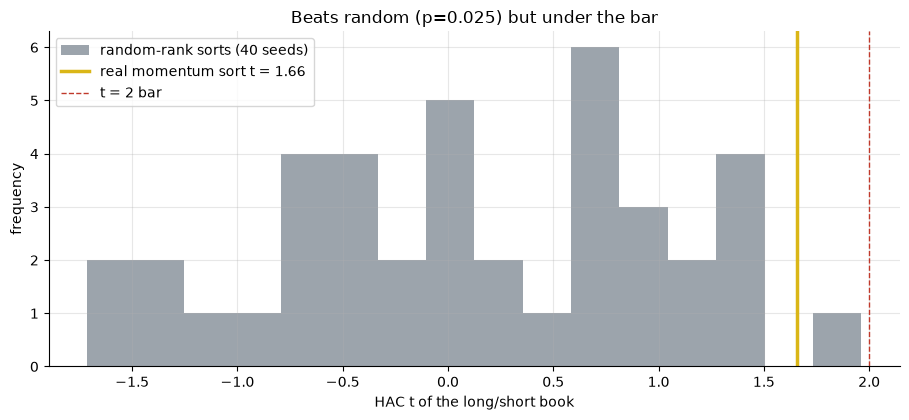

real t +1.66 | placebo mean t +0.11 (sd 0.91) | frac|t|>=2 0% | p 0.025


In [2]:
if HAVE_REAL:
    rep = st.momentum_report(MRET)
    print(f"L/S: {rep['mean_bps']:+.2f} bps/mo (~{rep['ann_pct']:+.2f}%/yr) over "
          f"{rep['n_months']} months")
    print(f"HAC t = {rep['hac_t']:+.3f} ({rep['hac_lags']} lags) | one-sample t = "
          f"{rep['one_sample_t']:+.3f} | Sharpe {rep['sharpe']:+.3f} | hit {rep['hit_rate']*100:.1f}%")
    pl = st.random_placebo(MRET); real_t, ts = pl['real_t'], pl['ts']
else:
    real_t = R['hac_t']
    ts = np.random.default_rng(792).normal(R['placebo_mean_t'], R['placebo_sd_t'], 40)
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.hist(ts, bins=16, color=GREY, alpha=.85, label='random-rank sorts (40 seeds)')
ax.axvline(real_t, c=AMBER, lw=2.5, label=f'real momentum sort t = {real_t:.2f}')
ax.axvline(2, ls='--', c=RED, lw=1, label='t = 2 bar')
ax.set_xlabel('HAC t of the long/short book'); ax.set_ylabel('frequency')
ax.set_title(f"Beats random (p={R['placebo_p']:.3f}) but under the bar")
ax.legend(); plt.tight_layout(); plt.show()
print(f"real t {real_t:+.2f} | placebo mean t {R['placebo_mean_t']:+.2f} "
      f"(sd {R['placebo_sd_t']:.2f}) | frac|t|>=2 {R['placebo_frac_ge2']:.0%} | p {R['placebo_p']:.3f}")

> 💡 In plain words: the sort earns **+84 bps/mo** and sits in the top ~2.5% of random-rank sorts (**p = 0.025**, 0/40 random sorts even reach |t| = 2) — it is *not* noise. But its own **HAC t = 1.66** is below the desk's t ≥ 2 certification bar. **H₁ fails on this tape; H₂ holds.** The gap between 'beats random' and 'certifiable' is exactly why the Signal stamp is `WEAK`, not `REAL`.

### 4b · Leg decomposition — winners, losers, or the basket?

Each leg measured **excess of the equal-weight basket**, so a plain long-only commodity tilt can't masquerade as momentum.

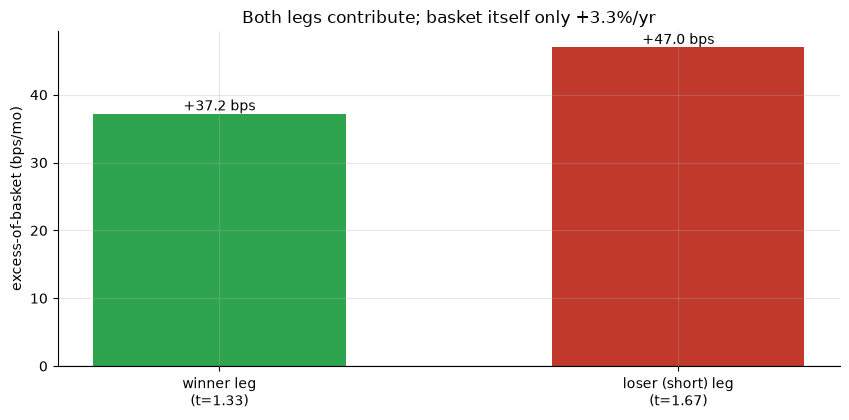

winner leg +37.21 bps (t=+1.33) | loser-short leg +47.01 bps (t=+1.67) | basket +3.29%/yr


In [3]:
if HAVE_REAL:
    lg = st.long_short_legs(MRET)
    lb, sb, bt = lg['long_excess_bps'], lg['short_excess_bps'], lg['basket_ann_pct']
    lt, stt = lg['long_t'], lg['short_t']
else:
    lb, sb, bt = R['long_bps'], R['short_bps'], R['basket_ann']
    lt, stt = R['long_t'], R['short_t']
fig, ax = plt.subplots(figsize=(8.6, 4.3))
ax.bar(['winner leg\n(t={:.2f})'.format(lt),'loser (short) leg\n(t={:.2f})'.format(stt)],
       [lb, sb], color=[GREEN, RED], width=.55)
for i,v in enumerate([lb, sb]): ax.annotate(f'{v:+.1f} bps',(i,v),ha='center',va='bottom')
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('excess-of-basket (bps/mo)')
ax.set_title(f'Both legs contribute; basket itself only {bt:+.1f}%/yr')
plt.tight_layout(); plt.show()
print(f'winner leg {lb:+.2f} bps (t={lt:+.2f}) | loser-short leg {sb:+.2f} bps (t={stt:+.2f}) | basket {bt:+.2f}%/yr')

> 💡 In plain words: the winner leg adds **+37 bps/mo** over the basket (t = 1.33) and the short-losers leg **+47 bps/mo** (t = 1.67) — the short side does slightly more work (it caught moves like the 2014-15 crude collapse). Neither leg clears t = 2 alone, and the equal-weight basket returned only +3.3%/yr — so this is a genuine relative-strength spread, not a disguised long-only commodity bet.

### 4c · Persistence — did it survive into the 2020s?

Split at 2019-01-01; within-era HAC *t* and a Welch *t* of the difference.

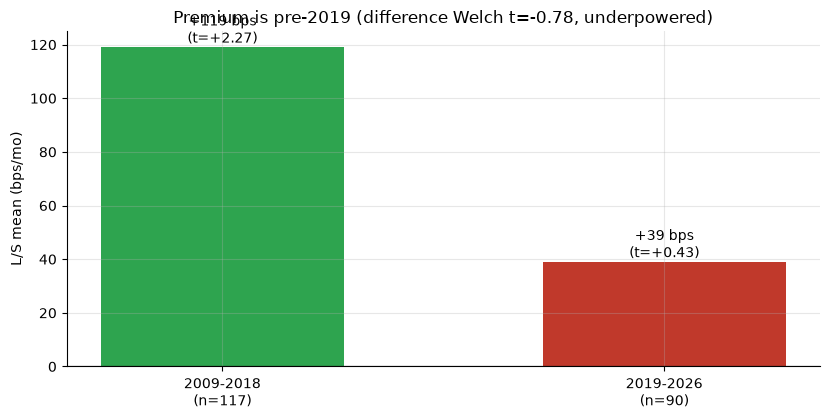

early +119.0 bps (t=+2.27) | late +39.0 bps (t=+0.43) | diff Welch t -0.78


In [4]:
if HAVE_REAL:
    sp = st.subperiod_contrast(MRET, data.ERA_SPLIT)
    e_b, l_b = sp['early_bps'], sp['late_bps']
    e_t, l_t, d_t = sp['early_t'], sp['late_t'], sp['welch_t_diff']
else:
    e_b, l_b = R['early_bps'], R['late_bps']
    e_t, l_t, d_t = R['early_t'], R['late_t'], R['diff_t']
fig, ax = plt.subplots(figsize=(8.4, 4.3))
ax.bar(['2009-2018\n(n={})'.format(R['early_n']),'2019-2026\n(n={})'.format(R['late_n'])],
       [e_b, l_b], color=[GREEN, RED], width=.55)
for i,(v,t_) in enumerate([(e_b,e_t),(l_b,l_t)]):
    ax.annotate(f'{v:+.0f} bps\n(t={t_:+.2f})',(i,v),ha='center',va='bottom')
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('L/S mean (bps/mo)')
ax.set_title(f'Premium is pre-2019 (difference Welch t={d_t:+.2f}, underpowered)')
plt.tight_layout(); plt.show()
print(f'early {e_b:+.1f} bps (t={e_t:+.2f}) | late {l_b:+.1f} bps (t={l_t:+.2f}) | diff Welch t {d_t:+.2f}')

> 💡 In plain words: the pre-2019 half clears the bar on its own (**+119 bps/mo, t = 2.27**); the post-2019 half is flat (**+39 bps/mo, t = 0.43**). The honesty rail: the *difference* test is underpowered (Welch t = -0.78), so we say **faded / not-supported-recently**, not *proven dead* — but there is no tradable premium in the recent tape. **H₃ fails.**

### 4d · The costed timer — and why costs aren't the killer here

One-way cost × traded notional; short leg pays 50 bps/yr borrow.

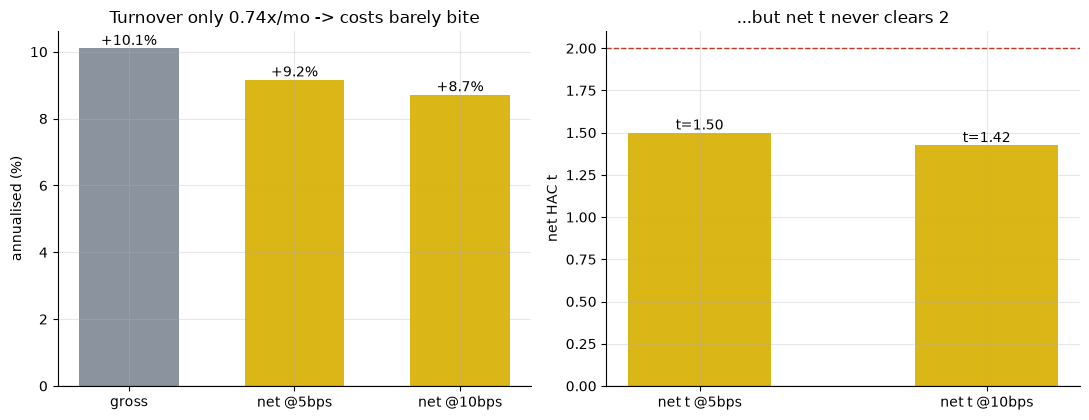

gross +10.1% -> net +9.2% (t=1.50) / +8.7% (t=1.42), turnover 0.74x


In [5]:
if HAVE_REAL:
    tm5 = st.costed_timer(MRET, cost_bps=5.0)
    tm10 = st.costed_timer(MRET, cost_bps=10.0)
    g = tm5['gross_ann_pct']; n5, n10 = tm5['net_ann_pct'], tm10['net_ann_pct']
    t5, t10 = tm5['net_t'], tm10['net_t']; to = tm5['avg_turnover']
else:
    g = R['timer5_gross']; n5, n10 = R['timer5_net'], R['timer10_net']
    t5, t10 = R['timer5_t'], R['timer10_t']; to = R['turnover']
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.0, 4.3))
a1.bar(['gross','net @5bps','net @10bps'], [g, n5, n10], color=[GREY, AMBER, AMBER], width=.6)
for i,v in enumerate([g, n5, n10]): a1.annotate(f'{v:+.1f}%',(i,v),ha='center',va='bottom')
a1.axhline(0, c='k', lw=.8); a1.set_ylabel('annualised (%)')
a1.set_title(f'Turnover only {to:.2f}x/mo -> costs barely bite')
a2.bar(['net t @5bps','net t @10bps'], [t5, t10], color=[AMBER, AMBER], width=.5)
for i,v in enumerate([t5, t10]): a2.annotate(f't={v:.2f}',(i,v),ha='center',va='bottom')
a2.axhline(2, ls='--', c=RED, lw=1); a2.axhline(0, c='k', lw=.8)
a2.set_ylabel('net HAC t'); a2.set_title('...but net t never clears 2')
plt.tight_layout(); plt.show()
print(f'gross {g:+.1f}% -> net {n5:+.1f}% (t={t5:.2f}) / {n10:+.1f}% (t={t10:.2f}), turnover {to:.2f}x')

> 💡 In plain words: monthly turnover is only **0.74× NAV**, so even at 10 bps/side + borrow the gross **+10%/yr** only falls to **+9%/yr** — costs are *not* the killer, unusually for this desk. What sinks tradability is that the **net HAC t (1.42) never clears 2**, the whole premium is pre-2019, and it's a 13-name survivor basket. **H₄: magnitude survives, certification doesn't → `FRAGILE`.**

### 4e · Faithful-engine & power control — we know the truth here

Synthetic AR(1)-trend panel with a TUNABLE planted momentum edge. The null (`mom_edge` = 0) is checked over **20 seeds** — never a single stream.

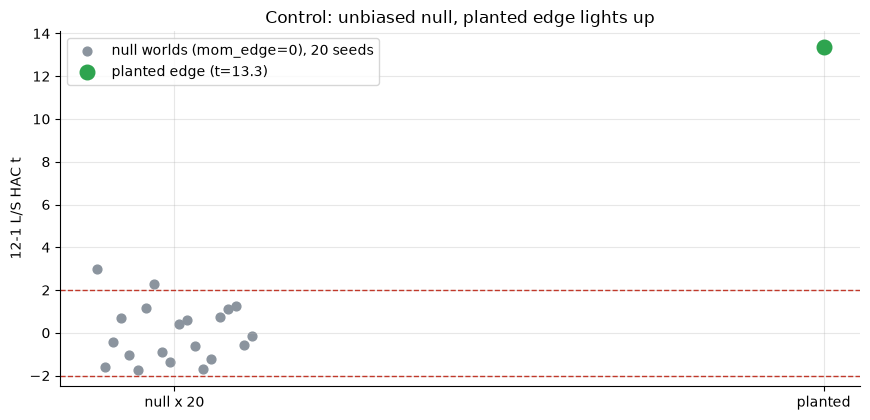

null: mean t -0.00 (sd 1.35), |t|>=2 in 2/20 | planted t +13.34


In [6]:
null_ts = np.array([st.synthetic_detect(data.synthetic_world(mom_edge=0.0, seed=792+s))['hac_t']
                    for s in range(20)])
planted = st.synthetic_detect(data.synthetic_world(mom_edge=1.0, seed=792))
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.scatter(np.linspace(-.12,.12,20), null_ts, color=GREY, s=40,
           label='null worlds (mom_edge=0), 20 seeds')
ax.scatter([1], [planted['hac_t']], color=GREEN, s=110, zorder=5,
           label=f"planted edge (t={planted['hac_t']:.1f})")
ax.axhline(2, ls='--', c=RED, lw=1); ax.axhline(-2, ls='--', c=RED, lw=1)
ax.set_xticks([0,1]); ax.set_xticklabels(['null x 20','planted'])
ax.set_ylabel('12-1 L/S HAC t')
ax.set_title('Control: unbiased null, planted edge lights up')
ax.legend(); plt.tight_layout(); plt.show()
print(f'null: mean t {null_ts.mean():+.2f} (sd {null_ts.std(ddof=1):.2f}), '
      f'|t|>=2 in {(abs(null_ts)>=2).sum()}/20 | planted t {planted["hac_t"]:+.2f}')

> 💡 In plain words: across 20 null worlds the detector averages t = -0.00 (unbiased) and fires |t| ≥ 2 on only 2/20 seeds — the ~5-10% false-positive rate you *expect* from noise, which is exactly why a synthetic control can never certify a real stamp. A planted edge reads t = 13.3 (+800 bps/mo). The sort works when momentum is there; on the real tape it reads 1.66. *(Machinery / power check only — never cited in support of the real-tape stamp.)*

## 5 · The verdict

- **Signal `WEAK`** — 12-1 L/S +84 bps/mo (~+10.1%/yr, Sharpe 0.41); **HAC t = 1.66 < 2**. Not noise (placebo p = 0.025) and literature-backed (Miffre-Rallis 2007), but this tape can't certify it, and the certifiable half is entirely pre-2019 (t = 2.27 early vs 0.43 late). Survivor basket — upper bound.
- **Tradability `FRAGILE`** — costs barely dent it (net +8.7%/yr @10bps) but net HAC t = 1.42 (uncertified), premium concentrated pre-2019, 13-name survivor universe with thin early breadth.
- **Recent half `NOT SUPPORTED`** — 2019-2026 HAC t = 0.43, Sharpe 0.17; the difference is underpowered (Welch t = -0.78), so *faded*, not *provably dead*.

## 6 · Going further

- **Longer history:** a continuous-futures tape (roll-adjusted) back to the 1990s would restore power the ETF era lacks — at the cost of roll noise. Does the recent fade hold there?
- **Bigger cross-section:** 13 ETFs is a thin sort (2-4 names per leg early). A 20-30 commodity futures panel (the Miffre-Rallis breadth) is the natural robustness extension.
- **Dedup map:** [507-cross-sectional-momentum](../../507-cross-sectional-momentum/) (same 12-1 sort, **equities**, `NONE`); [638-value-momentum-everywhere](../../638-value-momentum-everywhere/) (the mixed multi-asset value+momentum *combo*, commodities one sleeve of eight); the single-commodity **seasonality** studies (226, 307, 648-651 — *calendar* effects within one commodity, not cross-sectional strength).

*The reproducible core is offline and deterministic; frozen numbers live in [`docs/results.md`](../docs/results.md), sources in [`docs/references.md`](../docs/references.md).*